# CycleGAN: Monet Paintings ↔ Real Photos

This notebook trains a CycleGAN using the `monet2photo` dataset.

- Domain A: Monet paintings
- Domain B: Real photographs


![Cycle-GAN.jpg](https://i.imgur.com/7zGs6sY.jpeg)

In [ ]:
import os
import random
import zipfile
import urllib.request
from glob import glob

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

/home/lama/miniconda3/envs/rtx5070/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Hyperparameters

In [ ]:
epochs = 20
learning_rate = 2e-4
batch_size = 4
image_size = 128

lambda_cycle = 10
lambda_identity = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


## Download the Dataset

In [ ]:
dataset_url = "https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/monet2photo.zip"
zip_path = "monet2photo.zip"
data_dir = "monet2photo"

if not os.path.exists(data_dir):
    if not os.path.exists(zip_path):
        urllib.request.urlretrieve(dataset_url, zip_path)

    with zipfile.ZipFile(zip_path, "r") as zip_file:
        zip_file.extractall(".")

print("Dataset ready:", data_dir)

Dataset ready: monet2photo


## Prepare the Data

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((image_size + 30, image_size + 30)),
    transforms.RandomCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

In [ ]:
class UnpairedDataset(Dataset):
    def __init__(self, monet_dir, photo_dir, transform):
        self.monet_files = sorted(glob(os.path.join(monet_dir, "*")))
        self.photo_files = sorted(glob(os.path.join(photo_dir, "*")))
        self.transform = transform

    def __len__(self):
        return max(len(self.monet_files), len(self.photo_files))

    def __getitem__(self, index):
        monet_path = self.monet_files[index % len(self.monet_files)]
        photo_path = random.choice(self.photo_files)

        monet = Image.open(monet_path).convert("RGB")
        photo = Image.open(photo_path).convert("RGB")

        return self.transform(monet), self.transform(photo)


train_dataset = UnpairedDataset(
    os.path.join(data_dir, "trainA"),
    os.path.join(data_dir, "trainB"),
    train_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Monet images:", len(train_dataset.monet_files))
print("Photo images:", len(train_dataset.photo_files))

Monet images: 1072
Photo images: 6287


## Visualize the Two Domains

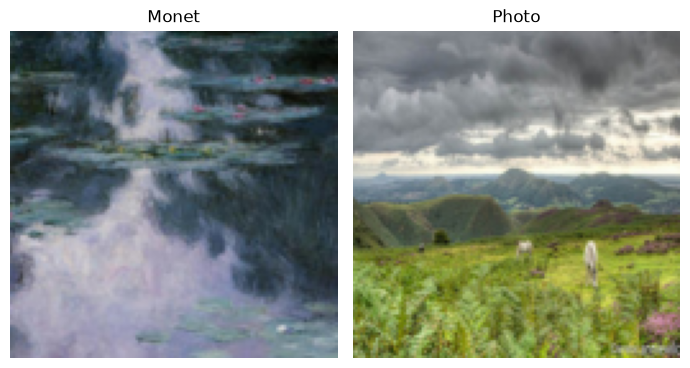

In [ ]:
monet_images, photo_images = next(iter(train_loader))

fig, axes = plt.subplots(1, 2, figsize=(7, 4))

axes[0].imshow(((monet_images[0] + 1) / 2).permute(1, 2, 0))
axes[0].set_title("Monet")
axes[0].axis("off")

axes[1].imshow(((photo_images[0] + 1) / 2).permute(1, 2, 0))
axes[1].set_title("Photo")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Generator

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels)
        )
        # Output = Original input + Learned changes
    def forward(self, x):
        return x + self.block(x)


class Generator(nn.Module):
    def __init__(self, residual_blocks=6):
        super().__init__()

        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(3, 64, 7),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True)
        ]

        channels = 64

        for _ in range(2):
            layers += [
                nn.Conv2d(channels, channels * 2, 3, 2, 1),
                nn.InstanceNorm2d(channels * 2),
                nn.ReLU(inplace=True)
            ]
            channels *= 2

        for _ in range(residual_blocks):
            layers.append(ResidualBlock(channels))

        for _ in range(2):
            layers += [
                nn.ConvTranspose2d(
                    channels,
                    channels // 2,
                    3,
                    2,
                    1,
                    output_padding=1
                ),
                nn.InstanceNorm2d(channels // 2),
                nn.ReLU(inplace=True)
            ]
            channels //= 2

        layers += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, 3, 7),
            nn.Tanh()
        ]

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

## PatchGAN Discriminator

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 1, 1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 1)
        )

    def forward(self, x):
        return self.model(x)

## Initialize the Models

In [ ]:
def initialize_weights(layer):
    if isinstance(layer, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(layer.weight, 0.0, 0.02)

        if layer.bias is not None:
            nn.init.constant_(layer.bias, 0)


g_photo_to_monet = Generator().to(device)
g_monet_to_photo = Generator().to(device)

d_monet = Discriminator().to(device)
d_photo = Discriminator().to(device)

g_photo_to_monet.apply(initialize_weights)
g_monet_to_photo.apply(initialize_weights)
d_monet.apply(initialize_weights)
d_photo.apply(initialize_weights)

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (9): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
  )
)

## Loss Functions and Optimizers

In [ ]:
adversarial_loss = nn.MSELoss()
#[(0.8-1)*2]
cycle_loss = nn.L1Loss()
#[0.5-0.7]fake-reconstructed
identity_loss = nn.L1Loss()
#g(real) = g(fake)
generator_optimizer = torch.optim.Adam(
    list(g_photo_to_monet.parameters()) +
    list(g_monet_to_photo.parameters()),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

monet_discriminator_optimizer = torch.optim.Adam(
    d_monet.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

photo_discriminator_optimizer = torch.optim.Adam(
    d_photo.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

## Replay Buffer

In [ ]:
class ReplayBuffer:
    def __init__(self, maximum_size=50):
        self.maximum_size = maximum_size
        self.images = []

    def push_and_pop(self, batch):
        output = []

        for image in batch.detach():
            image = image.unsqueeze(0)

            if len(self.images) < self.maximum_size:
                self.images.append(image)
                output.append(image)
            elif random.random() > 0.5:
                index = random.randrange(self.maximum_size)
                old_image = self.images[index].clone()
                self.images[index] = image
                output.append(old_image)
            else:
                output.append(image)

        return torch.cat(output, dim=0)


monet_buffer = ReplayBuffer()
photo_buffer = ReplayBuffer()

## Train CycleGAN

In [ ]:
generator_losses = []
monet_discriminator_losses = []
photo_discriminator_losses = []

for epoch in range(epochs):
    generator_total = 0
    monet_discriminator_total = 0
    photo_discriminator_total = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{epochs}",
        leave=False
    )

    for real_monet, real_photo in progress:
        real_monet = real_monet.to(device)
        real_photo = real_photo.to(device)

        generator_optimizer.zero_grad(set_to_none=True)

        identity_monet = g_photo_to_monet(real_monet)
        identity_photo = g_monet_to_photo(real_photo)

        loss_identity_monet = identity_loss(
            identity_monet,
            real_monet
        )

        loss_identity_photo = identity_loss(
            identity_photo,
            real_photo
        )

        fake_monet = g_photo_to_monet(real_photo)
        fake_photo = g_monet_to_photo(real_monet)

        monet_prediction = d_monet(fake_monet)
        photo_prediction = d_photo(fake_photo)

        loss_g_monet = adversarial_loss(
            monet_prediction,
            torch.ones_like(monet_prediction)
        )

        loss_g_photo = adversarial_loss(
            photo_prediction,
            torch.ones_like(photo_prediction)
        )

        reconstructed_photo = g_monet_to_photo(fake_monet)
        reconstructed_monet = g_photo_to_monet(fake_photo)

        loss_cycle_photo = cycle_loss(
            reconstructed_photo,
            real_photo
        )

        loss_cycle_monet = cycle_loss(
            reconstructed_monet,
            real_monet
        )

        generator_loss = (
            loss_g_monet +
            loss_g_photo +
            lambda_cycle * (
                loss_cycle_photo +
                loss_cycle_monet
            ) +
            lambda_identity * (
                loss_identity_monet +
                loss_identity_photo
            )
        )

        generator_loss.backward()
        generator_optimizer.step()

        monet_discriminator_optimizer.zero_grad(set_to_none=True)

        real_monet_prediction = d_monet(real_monet)
        real_monet_loss = adversarial_loss(
            real_monet_prediction,
            torch.ones_like(real_monet_prediction)
        )

        buffered_fake_monet = monet_buffer.push_and_pop(
            fake_monet
        )

        fake_monet_prediction = d_monet(
            buffered_fake_monet
        )

        fake_monet_loss = adversarial_loss(
            fake_monet_prediction,
            torch.zeros_like(fake_monet_prediction)
        )

        monet_discriminator_loss = (
            real_monet_loss + fake_monet_loss
        ) / 2

        monet_discriminator_loss.backward()
        monet_discriminator_optimizer.step()

        photo_discriminator_optimizer.zero_grad(set_to_none=True)

        real_photo_prediction = d_photo(real_photo)
        real_photo_loss = adversarial_loss(
            real_photo_prediction,
            torch.ones_like(real_photo_prediction)
        )

        buffered_fake_photo = photo_buffer.push_and_pop(
            fake_photo
        )

        fake_photo_prediction = d_photo(
            buffered_fake_photo
        )

        fake_photo_loss = adversarial_loss(
            fake_photo_prediction,
            torch.zeros_like(fake_photo_prediction)
        )

        photo_discriminator_loss = (
            real_photo_loss + fake_photo_loss
        ) / 2

        photo_discriminator_loss.backward()
        photo_discriminator_optimizer.step()

        generator_total += generator_loss.item()
        monet_discriminator_total += (
            monet_discriminator_loss.item()
        )
        photo_discriminator_total += (
            photo_discriminator_loss.item()
        )

    generator_losses.append(
        generator_total / len(train_loader)
    )

    monet_discriminator_losses.append(
        monet_discriminator_total / len(train_loader)
    )

    photo_discriminator_losses.append(
        photo_discriminator_total / len(train_loader)
    )

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"G: {generator_losses[-1]:.4f} | "
        f"D Monet: {monet_discriminator_losses[-1]:.4f} | "
        f"D Photo: {photo_discriminator_losses[-1]:.4f}"
    )

Epoch [1/20] G: 7.9217 | D Monet: 0.2690 | D Photo: 0.2787


Epoch [2/20] G: 6.5640 | D Monet: 0.2108 | D Photo: 0.2154


Epoch [3/20] G: 6.0790 | D Monet: 0.2084 | D Photo: 0.2077


Epoch [4/20] G: 5.7423 | D Monet: 0.2080 | D Photo: 0.2047


Epoch [5/20] G: 5.5742 | D Monet: 0.1981 | D Photo: 0.1958


...

Epoch [16/20] G: 4.4942 | D Monet: 0.1838 | D Photo: 0.1697


Epoch [17/20] G: 4.4929 | D Monet: 0.1812 | D Photo: 0.1685


Epoch [18/20] G: 4.4521 | D Monet: 0.1808 | D Photo: 0.1668


Epoch [19/20] G: 4.4101 | D Monet: 0.1779 | D Photo: 0.1655


Epoch [20/20] G: 4.3680 | D Monet: 0.1781 | D Photo: 0.1667


## Training Loss

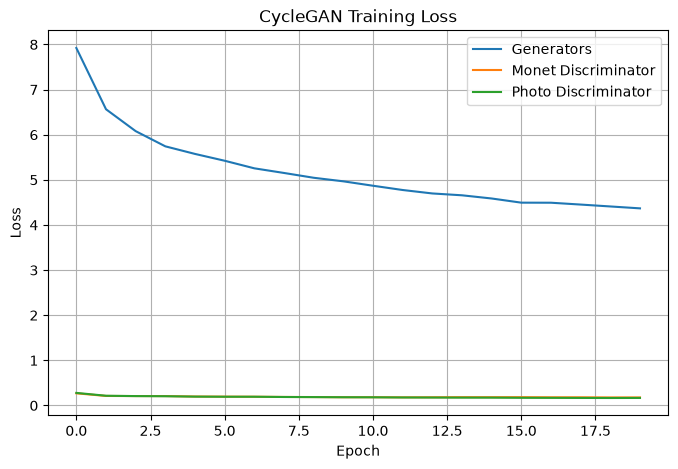

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(generator_losses, label="Generators")
plt.plot(
    monet_discriminator_losses,
    label="Monet Discriminator"
)
plt.plot(
    photo_discriminator_losses,
    label="Photo Discriminator"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CycleGAN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

## Test Photo → Monet

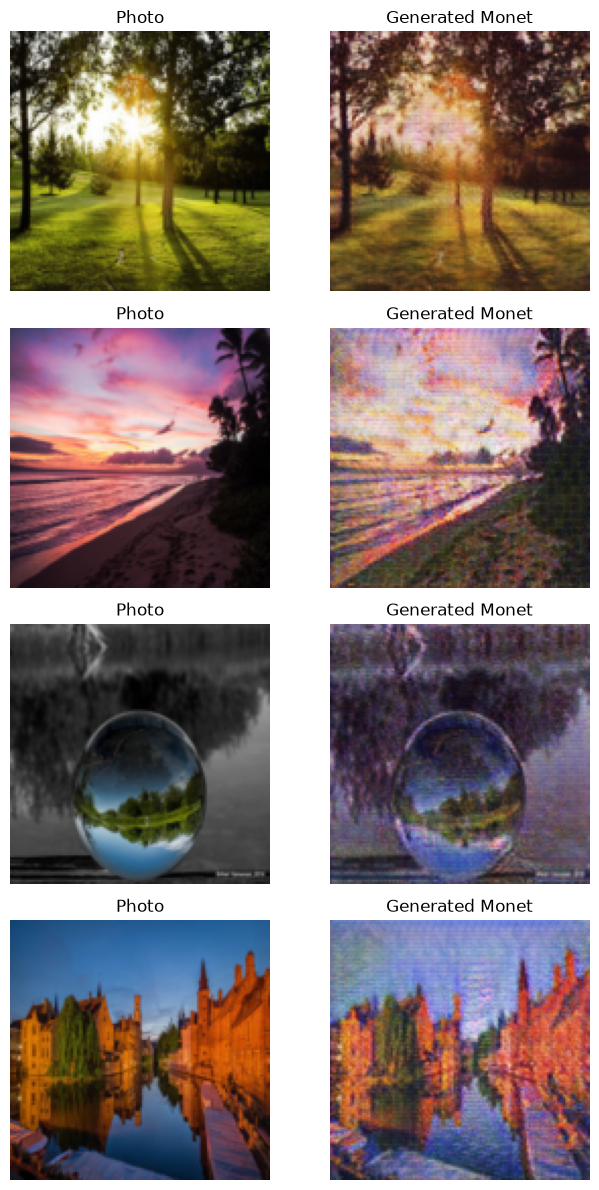

Generator(
  (model): Sequential(
    (0): ReflectionPad2d((3, 3, 3, 3))
    (1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1))
    (2): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (8): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (9): ReLU(inplace=True)
    (10): ResidualBlock(
      (block): Sequential(
        (0): ReflectionPad2d((1, 1, 1, 1))
        (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
        (2): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (3): ReLU(inplace=True)
        (4): ReflectionPad2d((1, 1, 1, 1))
        (5): C

In [ ]:
test_photo_files = sorted(
    glob(os.path.join(data_dir, "testB", "*"))
)

g_photo_to_monet.eval()

fig, axes = plt.subplots(4, 2, figsize=(7, 12))

with torch.no_grad():
    for row, image_path in enumerate(test_photo_files[:4]):
        image = Image.open(image_path).convert("RGB")
        photo = test_transform(image)
        photo = photo.unsqueeze(0).to(device)

        fake_monet = g_photo_to_monet(photo)

        photo = ((photo[0].cpu() + 1) / 2)
        photo = photo.permute(1, 2, 0)

        fake_monet = ((fake_monet[0].cpu() + 1) / 2)
        fake_monet = fake_monet.permute(1, 2, 0)

        axes[row, 0].imshow(photo)
        axes[row, 0].set_title("Photo")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(fake_monet.clamp(0, 1))
        axes[row, 1].set_title("Generated Monet")
        axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

g_photo_to_monet.train()

## Test Monet → Photo

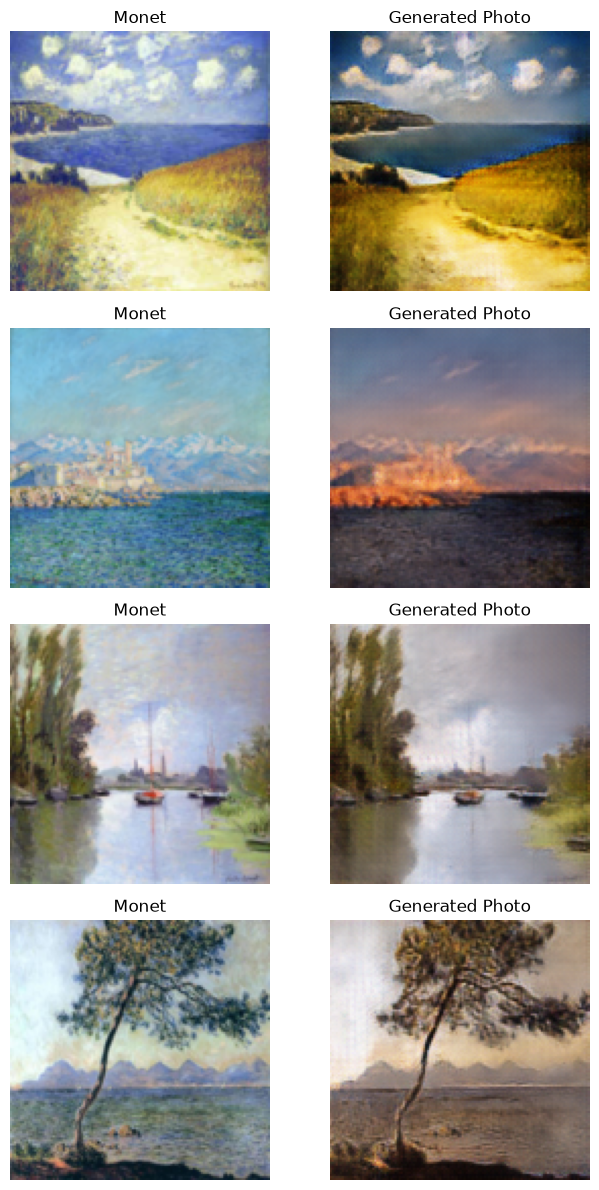

Generator(
  (model): Sequential(
    (0): ReflectionPad2d((3, 3, 3, 3))
    (1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1))
    (2): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (8): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (9): ReLU(inplace=True)
    (10): ResidualBlock(
      (block): Sequential(
        (0): ReflectionPad2d((1, 1, 1, 1))
        (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
        (2): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (3): ReLU(inplace=True)
        (4): ReflectionPad2d((1, 1, 1, 1))
        (5): C

In [ ]:
test_monet_files = sorted(
    glob(os.path.join(data_dir, "testA", "*"))
)

g_monet_to_photo.eval()

fig, axes = plt.subplots(4, 2, figsize=(7, 12))

with torch.no_grad():
    for row, image_path in enumerate(test_monet_files[:4]):
        image = Image.open(image_path).convert("RGB")
        monet = test_transform(image)
        monet = monet.unsqueeze(0).to(device)

        fake_photo = g_monet_to_photo(monet)

        monet = ((monet[0].cpu() + 1) / 2)
        monet = monet.permute(1, 2, 0)

        fake_photo = ((fake_photo[0].cpu() + 1) / 2)
        fake_photo = fake_photo.permute(1, 2, 0)

        axes[row, 0].imshow(monet)
        axes[row, 0].set_title("Monet")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(fake_photo.clamp(0, 1))
        axes[row, 1].set_title("Generated Photo")
        axes[row, 1].axis("off")

plt.tight_layout()
plt.show()


###  by : Lama Ayash